![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Final Project - Design

#### By: Sergi Nàcher Muñoz

## 0. Imports 

### 0.1. General libraries

In [4]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

### 0.2. Materials

In [5]:
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Part I. Design and Simulation of Individual Components 

## 1. Simulating Propagation Modes in SOI Waveguides

### 1.1. Define the SOI waveguide structure (450 nm width, 220 nm thickness). 

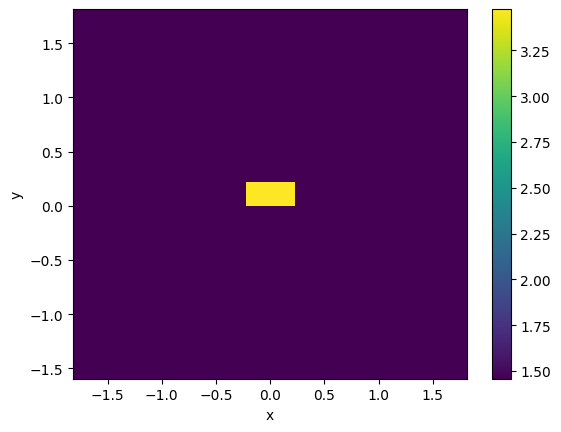

In [10]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = 1550 * nm, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)

deep_waveguide.plot_index()

### 1.2. Simulate fundamental TE and TM modes. 

In [11]:
deep_waveguide.n_eff

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\

12:56:13 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 3 does not decay at the plane boundaries.  

12:56:14 Hora estándar romance WARNING: The group index was not computed. To    
                               calculate group index, pass 'group_index_step =  
                               True' in the 'ModeSpec'.                         

2026-03-23 12:56:14.033 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_198a1ab0a96c4a6f.npz.


array([2.33508782+7.05715980e-05j, 1.7447082 +2.39341986e-04j,
       1.46251286+2.05632472e-04j, 1.43196857+2.18207211e-04j])

In [12]:
deep_waveguide.fraction_te

array([0.960726  , 0.06940437, 0.64309704, 0.99810644])

In [13]:
deep_waveguide.fraction_tm

array([0.039274  , 0.93059563, 0.35690296, 0.00189356])

Text(0.5, 1.0, 'Modo 0 - Campo Ex (Modo TE0)')

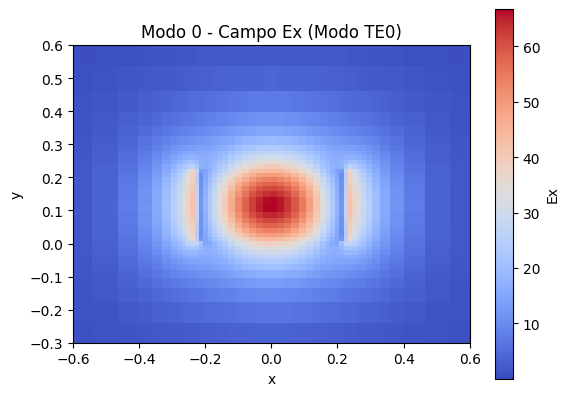

In [25]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 0 - Campo Ex (Modo TE0)')

Text(0.5, 1.0, 'Modo 1 - Campo Ey (Modo TM0)')

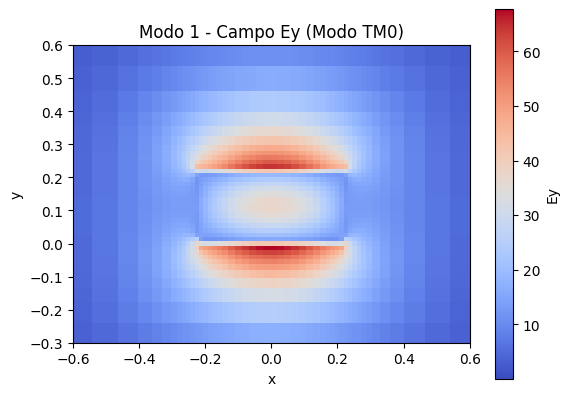

In [30]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 1 - Campo Ey (Modo TM0)')

Para el modo fundamental TM0 se puede observar un campo poco confinado en el núcleo, y en su lugar la luz viaja por el cladding.

Ya tenemos los modos fundamentales tanto para TE como para TM. Ahora vamos a verificar que los demás modos están en corte

Text(0.5, 1.0, 'Modo 2 - Campo Ex')

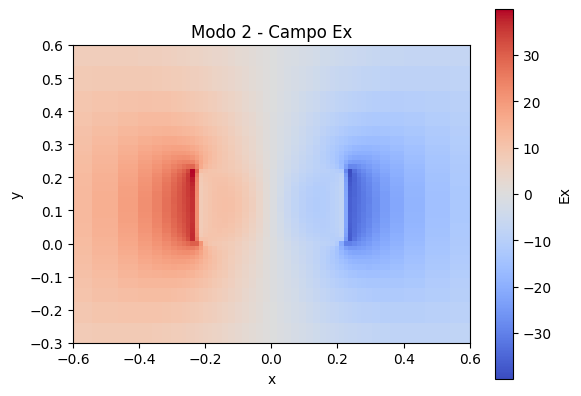

In [38]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ex')

Text(0.5, 1.0, 'Modo 2 - Campo Ey')

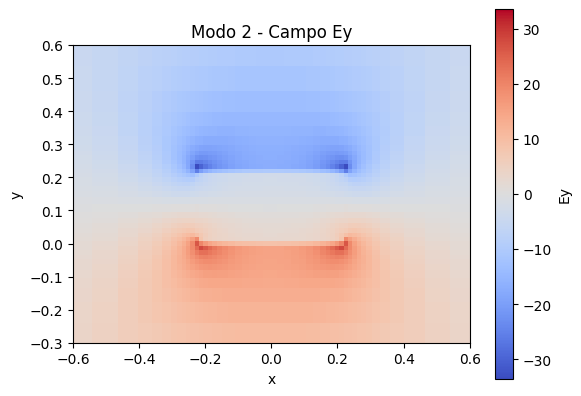

In [39]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ey')

Por tanto, hemos verificado que los siguientes modos estarán en corte como ya se había previsto.

### 1.3. Extract effective index (n_eff) and group index (n_g) values. 

In [42]:
# Índice efectivo TE0 y TM0

n_eff_TE = deep_waveguide.n_eff.real[0]
n_eff_TM = deep_waveguide.n_eff.real[1]
print(f"Índice efectivo del modo TE0: {n_eff_TE:.4f}")
print(f"Índice efectivo del modo TM0: {n_eff_TM:.4f}")

Índice efectivo del modo TE0: 2.3351
Índice efectivo del modo TM0: 1.7447


In [50]:
# Índice de grupo TE0 y TM0
n_g = n_eff_TE - n_eff_TM * (deep_waveguide.n_eff.imag[0] / deep_waveguide.n_eff.real[0])

print(f"Índice de grupo del modo TE0: {n_g:.4f}")

Índice de grupo del modo TE0: 2.3350
